<a href="https://colab.research.google.com/github/RvXp/Topicos-Especiais-em-IA-LLM/blob/main/one_head_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import random
import torch.nn.functional as F

chars = list("abcd ")
vocab = {ch: i for i, ch in enumerate(chars)} # Cada letra, ganha um número
inv_vocab = {i: ch for ch, i in vocab.items()}# Tabela de decodificação
vocab_size = len(vocab)

def encode(s): # Codifica letras em números
    return torch.tensor([vocab[c] for c in s], dtype=torch.long)

def decode(t): # Decodifica números em letras
    return ''.join(inv_vocab[int(x)] for x in t)

def random_seq(n=6): # Cria novas sequências
    return ''.join(random.choice(chars[:-1]) for _ in range(n))

# Gerar dados
pairs = [(encode(s), encode(s[::-1])) for s in [random_seq() for _ in range(50000)]]

max_len = max(len(x) for x, _ in pairs) # pega maior sequência

def pad(x):  # Preenche conjunto de dados em pad no último índice
    return torch.cat([x, torch.tensor([vocab[' ']] * (max_len - len(x)))], dim=0)

inputs = torch.stack([pad(x) for x, _ in pairs])
targets = torch.stack([pad(y) for _, y in pairs])

train_ds = torch.utils.data.TensorDataset(inputs, targets)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
print(pairs[1])

(tensor([2, 1, 2, 3, 2, 1]), tensor([1, 2, 3, 2, 1, 2]))


In [3]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_size)
        self.gru = nn.GRU(emb_size, hidden_size, batch_first=True)

    def forward(self, x):
        x = self.embed(x)
        outputs, h = self.gru(x)
        return outputs, h   # <--- ESSENCIAL

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class OneHeadAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        # Projeções lineares para Q, K, V
        self.W_q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_v = nn.Linear(hidden_size, hidden_size, bias=False)

        # fator de escala (1 / sqrt(d_k))
        self.scale = hidden_size ** -0.5

    def forward(self, decoder_hidden, encoder_outputs):
        """
        decoder_hidden: (B, 1, H)
        encoder_outputs: (B, S, H)

        Retorna:
          context: (B, 1, H)
          attn_weights: (B, 1, S)
        """

        # ---- 1) Projeções Q, K, V ----
        # Q: usa o hidden do decoder
        Q = self.W_q(decoder_hidden)       # (B, 1, H)

        # K, V: usam os outputs do encoder
        K = self.W_k(encoder_outputs)      # (B, S, H)
        V = self.W_v(encoder_outputs)      # (B, S, H)

        # ---- 2) Scaled Dot-Product Attention ----
        # score = Q · K^T / sqrt(d_k)
        attn_scores = torch.bmm(Q, K.transpose(1, 2))  # (B, 1, S)
        attn_scores = attn_scores * self.scale

        # softmax sobre S
        attn_weights = F.softmax(attn_scores, dim=-1)  # (B, 1, S)

        # ---- 3) Contexto = soma ponderada dos valores V ----
        context = torch.bmm(attn_weights, V)           # (B, 1, H)

        return context, attn_weights

In [5]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_size)
        self.gru = nn.GRU(emb_size, hidden_size, batch_first=True)
        self.attn = OneHeadAttention(hidden_size)

        self.fc = nn.Linear(hidden_size * 2, vocab_size)

    def forward(self, x, h, encoder_outputs):
        """
        x: tokens anteriores corretos  (B, T)
        h: estado inicial do decoder   (1, B, H)
        encoder_outputs: todos os h_s  (B, S, H)
        """
        x = self.embed(x)  # (B, T, E)

        outputs = []
        seq_len = x.size(1)
        hidden = h

        for t in range(seq_len):
            inp = x[:, t:t+1]  # (B, 1, E)

            out_t, hidden = self.gru(inp, hidden)   # out_t: (B,1,H)

            # Atenção
            context, attn_w = self.attn(out_t, encoder_outputs)

            # concatenação [out_t ; context]
            combined = torch.cat([out_t, context], dim=-1)

            logits = self.fc(combined)  # (B,1,V)
            outputs.append(logits)

        outputs = torch.cat(outputs, dim=1)  # (B, T, V)
        return outputs, hidden


In [6]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        encoder_outputs, h = self.encoder(src)
        logits, _ = self.decoder(tgt[:, :-1], h, encoder_outputs)
        return logits

In [7]:
def decode_step(decoder, token, h, encoder_outputs):
    """
    Executa um passo de decodificação:
    - token: tensor (B,1)
    - h: estado oculto do decoder (1,B,H)
    - encoder_outputs: (B,S,H)
    """
    logits, h = decoder(token, h, encoder_outputs)  # (B,1,V)
    next_token = logits[:, -1, :].argmax(-1, keepdim=True)  # (B,1)
    return next_token, h


def predict(model, seq, max_len=10):
    model.eval()
    with torch.no_grad():
        # codifica entrada
        src = pad(encode(seq)).unsqueeze(0).to(device, dtype=torch.long)

        # encoder agora retorna (encoder_outputs, h)
        encoder_outputs, h = model.encoder(src)

        # token inicial (ex: espaço ou )
        token = torch.tensor([[vocab[' ']]], dtype=torch.long, device=device)

        seq_invertida = []
        for _ in range(max_len):
            token, h = decode_step(model.decoder, token, h, encoder_outputs)
            seq_invertida.append(token.item())

        return decode(seq_invertida)

In [8]:
emb_size = 64
hidden_size = 64
encoder = Encoder(vocab_size, emb_size, hidden_size)
decoder = Decoder(vocab_size, emb_size, hidden_size)
model = Seq2Seq(encoder, decoder).to(device)

loss_fn = nn.CrossEntropyLoss(ignore_index=vocab[' ']) # ignora o pad: " "
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

In [9]:
for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device, dtype=torch.long), yb.to(device, dtype=torch.long)
        opt.zero_grad()
        logits = model(xb, yb)
        loss = loss_fn(logits.reshape(-1, vocab_size), yb[:, 1:].reshape(-1))
        loss.backward()
        opt.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}: loss={total_loss/len(train_dl):.4f}")

Epoch 1: loss=0.2012
Epoch 2: loss=0.0124
Epoch 3: loss=0.0006
Epoch 4: loss=0.0002
Epoch 5: loss=0.0001
Epoch 6: loss=0.0001
Epoch 7: loss=0.0000
Epoch 8: loss=0.0000
Epoch 9: loss=0.0000
Epoch 10: loss=0.0000


In [13]:
count = 0
total_letras_corretas = 0
total_letras_avaliadas = 0
for _ in range(100):
    s = random_seq()
    alvo = s[::-1]
    pred = predict(model, s, max_len=len(s))
    if s == pred[::-1]:
        count += 1
    letras_corretas = sum(1 for char_alvo, char_pred in zip(alvo, pred) if char_alvo == char_pred)
    print(f"{s} -> {pred} : Acertou {letras_corretas} letras")
    total_letras_corretas += letras_corretas
    total_letras_avaliadas += len(alvo)
media_letras = total_letras_corretas / 100
print(f"Media de acertos: {media_letras}")
print(f"total de acertos: {count}")

cdbbdd -> ddbbcd : Acertou 4 letras
cacbaa -> aabccc : Acertou 5 letras
dcddbd -> ddbdcd : Acertou 4 letras
aacddd -> dddaac : Acertou 4 letras
cdadcc -> cdadcc : Acertou 2 letras
cbcccc -> ccccbc : Acertou 6 letras
badadc -> dacdab : Acertou 3 letras
adbdbd -> ddbbaa : Acertou 3 letras
ddadad -> dadadd : Acertou 6 letras
accaaa -> aaacaa : Acertou 5 letras
ccbbba -> abbbcc : Acertou 6 letras
cacbca -> acbacc : Acertou 4 letras
accbdb -> bdbcaa : Acertou 5 letras
cdddbd -> ddbdcc : Acertou 3 letras
bdbbba -> abbbdb : Acertou 6 letras
aacccb -> bccaaa : Acertou 5 letras
adcdac -> adcdaa : Acertou 1 letras
aaabbb -> bbaaaa : Acertou 5 letras
cabbca -> abcacc : Acertou 2 letras
cdbcdd -> dddcbc : Acertou 3 letras
daabda -> adabdd : Acertou 3 letras
bbdbcd -> dcdbbb : Acertou 4 letras
dcddba -> adbddc : Acertou 2 letras
baaccd -> dcaabb : Acertou 4 letras
dcddac -> adcddd : Acertou 2 letras
cbcdcd -> ddccbc : Acertou 4 letras
adddac -> addcad : Acertou 1 letras
aacaba -> abacaa : Acertou 6

In [11]:
import numpy as np

total_params = 0
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        num_params = np.prod(parameter.size())
        print(f"Parâmetro '{name}': {num_params} parâmetros")
        total_params += num_params

print(f"\nNúmero total de parâmetros treináveis: {total_params}")

Parâmetro 'encoder.embed.weight': 320 parâmetros
Parâmetro 'encoder.gru.weight_ih_l0': 12288 parâmetros
Parâmetro 'encoder.gru.weight_hh_l0': 12288 parâmetros
Parâmetro 'encoder.gru.bias_ih_l0': 192 parâmetros
Parâmetro 'encoder.gru.bias_hh_l0': 192 parâmetros
Parâmetro 'decoder.embed.weight': 320 parâmetros
Parâmetro 'decoder.gru.weight_ih_l0': 12288 parâmetros
Parâmetro 'decoder.gru.weight_hh_l0': 12288 parâmetros
Parâmetro 'decoder.gru.bias_ih_l0': 192 parâmetros
Parâmetro 'decoder.gru.bias_hh_l0': 192 parâmetros
Parâmetro 'decoder.attn.W_q.weight': 4096 parâmetros
Parâmetro 'decoder.attn.W_k.weight': 4096 parâmetros
Parâmetro 'decoder.attn.W_v.weight': 4096 parâmetros
Parâmetro 'decoder.fc.weight': 640 parâmetros
Parâmetro 'decoder.fc.bias': 5 parâmetros

Número total de parâmetros treináveis: 63493


Input: abcab
Predicted: bacbaa


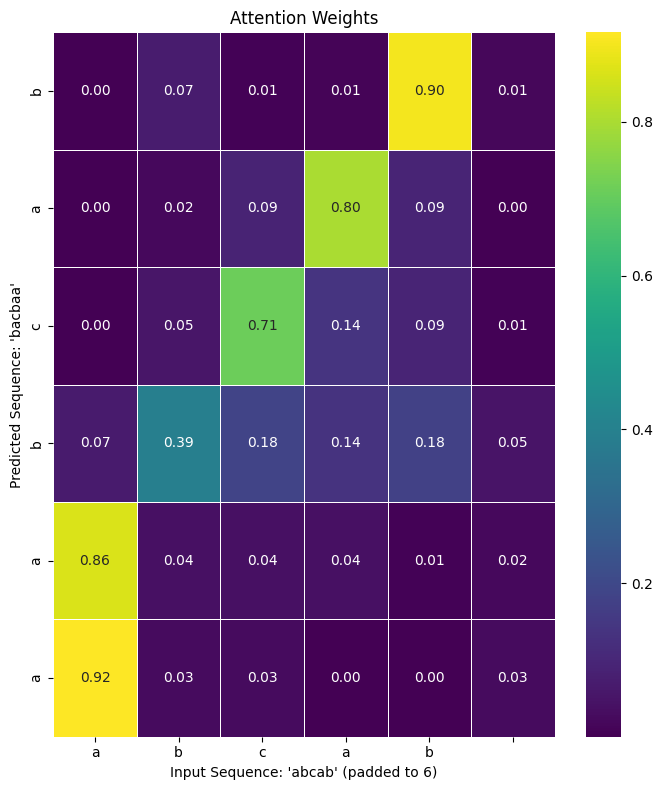

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def predict_and_attention_matrix(model, input_str):
    model.eval()
    with torch.no_grad():
        src = pad(encode(input_str)).unsqueeze(0).to(device, dtype=torch.long)
        encoder_outputs, h = model.encoder(src)
        token = torch.tensor([[vocab[' ']]], dtype=torch.long, device=device)

        decoded_tokens = []
        attention_weights_history = []

        for _ in range(max_len):
            input_token_embedding = model.decoder.embed(token)
            out_t, h = model.decoder.gru(input_token_embedding, h)
            context, attn_w = model.decoder.attn(out_t, encoder_outputs)
            attention_weights_history.append(attn_w.squeeze().cpu().numpy())
            combined = torch.cat([out_t, context], dim=-1)
            logits = model.decoder.fc(combined)
            next_token = logits.argmax(-1)
            decoded_tokens.append(next_token.item())
            token = next_token

        attention_matrix = np.array(attention_weights_history)

        return decode(decoded_tokens), attention_matrix

input_sequence = "abcab"
predicted_sequence, attention_matrix_plot = predict_and_attention_matrix(model, input_sequence)

print(f"Input: {input_sequence}")
print(f"Predicted: {predicted_sequence}")

plt.figure(figsize=(len(input_sequence) + 2, len(predicted_sequence) + 2))
sns.heatmap(attention_matrix_plot,
            xticklabels=[c for c in input_sequence] + [' '] * (max_len - len(input_sequence)),
            yticklabels=[c for c in predicted_sequence],
            cmap='viridis',
            annot=True,
            fmt=".2f",
            linewidths=.5)
plt.xlabel(f"Input Sequence: '{input_sequence}' (padded to {max_len})")
plt.ylabel(f"Predicted Sequence: '{predicted_sequence}'")
plt.title("Attention Weights")
plt.tight_layout()
plt.show()